In [1]:
import sys
import os
import matplotlib.pyplot as plt
import torch
import gc

### Loading ENV VAR 

In [2]:
from dotenv import load_dotenv
load_dotenv(override=True)  # ensure new values overwrite old ones

# GENERAL PATHS
PROJECT_ROOT = os.getenv("PROJECT_ROOT")

# This makes kernel to see for modules in parent directory
sys.path.append(PROJECT_ROOT)
from src.prepare import TACODataProcessor
from src.train import LitterDetectionTrainer
from config.model_config import model_configs

In [3]:
# DATA PATH CONFIGURATION with respect to train.ipynb file
RAW_DATA = os.getenv("RAW_DATA_PATH")
PROCESSED_DATA = os.getenv("PROCESSED_DATA_PATH")
DATA_YAML = os.getenv("DATA_YAML_PATH")

# RUN PATHS
RUN_PATH = os.getenv('RUN_PATH')

print(PROJECT_ROOT)
print(os.getcwd())
print(RAW_DATA)
print(DATA_YAML)
print(RUN_PATH)

/home/luc/ai-ml/MLOPS/PROJECT
/home/luc/ai-ml/MLOPS/PROJECT/train
/home/luc/ai-ml/MLOPS/PROJECT/data/taco_data
/home/luc/ai-ml/MLOPS/PROJECT/config/data_config.yaml
/home/luc/ai-ml/MLOPS/PROJECT/runs


## Phase - 1 : Data Preparation with OpenCV

1. In this phase I will first split dataset into three categories train, val and test.
2. After splitting I will augment the dataset on training samples only.
3. Val and test samples are not augmented, so that they remain real and unbiased, which gives a true estimate of performance.

In [4]:
print("\n" + "="*70)
print("STEP 1: DATA PREPARATION")
print("="*70)

processor = TACODataProcessor(
    taco_path=RAW_DATA,
    output_path=PROCESSED_DATA,
    train_split=0.7,
    val_split=0.2
)
processor.process_dataset()


STEP 1: DATA PREPARATION
Starting TACO dataset processing...
/home/luc/ai-ml/MLOPS/PROJECT/data/taco_data/annotations.json
loading annotations into memory...
Done (t=0.29s)
creating index...
index created!

Processing train split (1049 images)...


Processing train: 100%|██████████| 1049/1049 [02:31<00:00,  6.91it/s]



Processing val split (300 images)...


Processing val: 100%|██████████| 300/300 [00:42<00:00,  7.00it/s]



Processing test split (151 images)...


Processing test: 100%|██████████| 151/151 [00:24<00:00,  6.09it/s]

Dataset processing completed!


Found 1049 images.


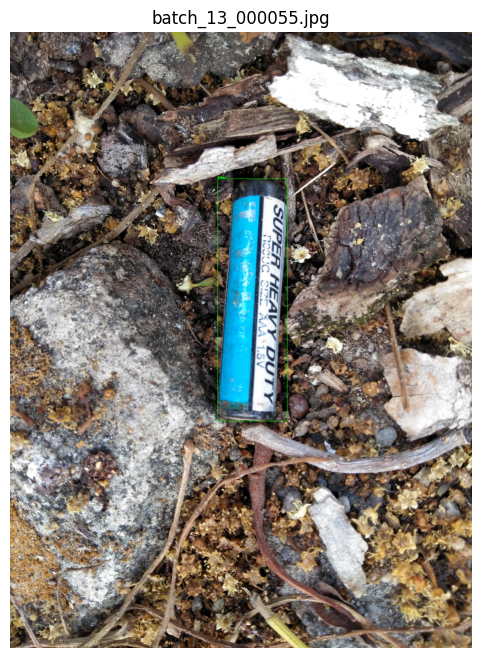

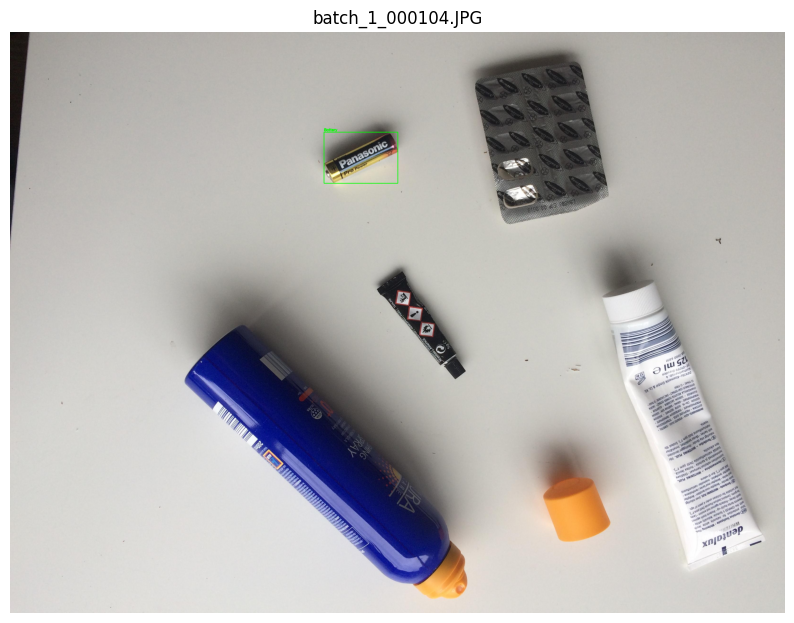

In [5]:
import os
import cv2
import matplotlib.pyplot as plt

def visualize_only_class(image_dir, label_dir, target_class_id=1, class_name="Aluminium foil"):
    image_files = [f for f in os.listdir(image_dir)
                   if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    print(f"Found {len(image_files)} images.")

    for img_name in image_files:
        img_path = os.path.join(image_dir, img_name)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        height, width = img.shape[:2]

        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        contains_target = False

        for line in lines:
            class_id, x_center, y_center, w, h = map(float, line.strip().split())
            class_id = int(class_id)

            # ❗ Skip if NOT the target class
            if class_id != target_class_id:
                continue

            contains_target = True

            # Convert normalized YOLO → pixel coords
            x_center *= width
            y_center *= height
            w *= width
            h *= height

            x1 = int(x_center - w/2)
            y1 = int(y_center - h/2)
            x2 = int(x_center + w/2)
            y2 = int(y_center + h/2)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, class_name, (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

        # Only show images that contain the target class
        if contains_target:
            plt.figure(figsize=(10, 8))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(img_name)
            plt.axis('off')
            plt.show()


# Run it
visualize_only_class(
    image_dir="/home/luc/ai-ml/MLOPS/PROJECT/data/taco_data_processed/train/images",
    label_dir="/home/luc/ai-ml/MLOPS/PROJECT/data/taco_data_processed/train/labels",
    target_class_id=1,
    class_name="Battery"
)


In [16]:
import os
from collections import Counter

# Path to your label folder
label_dir = "/home/luc/ai-ml/MLOPS/PROJECT/data/taco_data_processed/train/labels"

# Get all label files
labels = [os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".txt")]

# Count occurrences of each class
c = Counter()
for label_file in labels:
    with open(label_file, "r") as f:
        for line in f:
            cid = int(line.strip().split()[0])
            c[cid] += 1

# Print sorted by class_id
for class_id in sorted(c):
    print(f"Class {class_id}: {c[class_id]} instances")

Class 0: 48 instances
Class 1: 2 instances
Class 2: 6 instances
Class 4: 30 instances
Class 5: 193 instances
Class 6: 79 instances
Class 7: 142 instances
Class 8: 54 instances
Class 9: 135 instances
Class 10: 26 instances
Class 11: 7 instances
Class 12: 157 instances
Class 13: 4 instances
Class 14: 67 instances
Class 15: 8 instances
Class 16: 29 instances
Class 17: 50 instances
Class 18: 22 instances
Class 19: 3 instances
Class 20: 46 instances
Class 21: 77 instances
Class 22: 8 instances
Class 23: 5 instances
Class 24: 1 instances
Class 25: 3 instances
Class 26: 3 instances
Class 27: 54 instances
Class 28: 7 instances
Class 29: 195 instances
Class 30: 3 instances
Class 31: 30 instances
Class 32: 8 instances
Class 33: 65 instances
Class 34: 13 instances
Class 36: 318 instances
Class 37: 4 instances
Class 38: 25 instances
Class 39: 192 instances
Class 40: 48 instances
Class 41: 2 instances
Class 42: 30 instances
Class 43: 7 instances
Class 44: 3 instances
Class 45: 28 instances
Class 46

In [ ]:
print("")

train: 1049 images
val: 300 images
test: 151 images


## Phase - 2: Model Training

1) First initializing dagshub and mlflow for model tracking


In [5]:
# Checking Configuration of yolo
from ultralytics import settings
print(settings)

JSONDict("/home/luc/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/home/luc/ai-ml/MLOPS/PROJECT/train/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "080dd5c69bca2800a472c9cb03e3a6d3e0cb3ba856fcf24512dcc3a26c6843a7",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}


### Training first model

In [4]:
config_name = "yolov8n_baseline"
config = model_configs["yolov8n_baseline"]

trainer = LitterDetectionTrainer(
    data_yaml=DATA_YAML,
    model_name=config["model_name"],
    experiment_name="litter-detection-taco"
)

model, results = trainer.train(
    epochs=config.get("epochs", 100),
    img_size=config.get("img_size", 640),
    batch_size=config.get("batch_size", 16),
    device=config.get("device", "cuda"),
    optimizer=config.get("optimizer", "SGD"),
    lr=config.get("lr", 0.01),
    fraction=config.get("fraction", 1.0),
    patience=config.get("patience", 50),
    augmentation=config.get("augmentation_config", None),
    tags=config.get("tags", None),
    project=RUN_PATH,
    name=config_name  # Use config_name to differentiate runs
)


print(f"✅ Completed training for {config_name}\n")

2025/12/09 18:06:03 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


🚀 Starting training...
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/luc/ai-ml/MLOPS/PROJECT/config/data_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer

2025/12/09 18:06:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


MLflow: logging run_id(5d44acea16034e7da8f32061d93f730d) to https://dagshub.com/abdullahsyed2005/litter-detection.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/luc/ai-ml/MLOPS/PROJECT/runs/yolov8n_baseline
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      2.64G      1.208      5.244      1.159         41        640: 100% ━━━━━━━━━━━━ 66/66 3.8it/s 17.4s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.4it/s 3.0s.3ss
                   all        300        967     0.0108      0.017    0.00847    0.00734

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      2.65G      1.303      4.521      1.182         38        640: 100% ━━━━━━━━━━━━ 66/66 4.7it/s 14.1s0.2s
                 Class     Images  Instances

In [6]:
config_name = "yolov8s_baseline"
config = model_configs[config_name]

trainer = LitterDetectionTrainer(
    data_yaml=DATA_YAML,
    model_name=config["model_name"],
    experiment_name="litter-detection-taco"
)

model, results = trainer.train(
    epochs=config.get("epochs", 100),
    img_size=config.get("img_size", 640),
    batch_size=config.get("batch_size", 16),
    device=config.get("device", "cuda"),
    optimizer=config.get("optimizer", "SGD"),
    lr=config.get("lr", 0.01),
    fraction=config.get("fraction", 1.0),
    patience=config.get("patience", 50),
    augmentation=config.get("augmentation_config", None),
    tags=config.get("tags", None),
    project=RUN_PATH,
    name=config_name  # Use config_name to differentiate runs
)


print(f"✅ Completed training for {config_name}\n")

2025/12/09 16:38:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/09 16:38:40 INFO mlflow.tracking.fluent: Autologging successfully enabled for transformers.


🚀 Starting training...
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/luc/ai-ml/MLOPS/PROJECT/config/data_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer

2025/12/09 16:38:57 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/09 16:38:57 INFO mlflow.tracking.fluent: Autologging successfully enabled for transformers.


MLflow: logging run_id(6ec5a70055da413eba7460810dd45d3f) to https://dagshub.com/abdullahsyed2005/litter-detection.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/luc/ai-ml/MLOPS/PROJECT/runs/yolov8s_baseline
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/150      4.01G      1.205      5.489      1.237         41        640: 100% ━━━━━━━━━━━━ 66/66 1.7it/s 39.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.4it/s 7.3s.8ss
                   all        300        967      0.368     0.0647     0.0336     0.0281

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/150      3.55G      1.114      3.528      1.157         38        640: 100% ━━━━━━━━━━━━ 66/66 2.4it/s 27.2s0.3ss
                 Class     Images  Instanc

In [4]:
config_name = "yolov8s_adam_optimizer"
config = model_configs[config_name]

trainer = LitterDetectionTrainer(
    data_yaml=DATA_YAML,
    model_name=config["model_name"],
    experiment_name="litter-detection-taco"
)

model, results = trainer.train(
    epochs=config.get("epochs", 100),
    img_size=config.get("img_size", 640),
    batch_size=config.get("batch_size", 16),
    device=config.get("device", "cuda"),
    optimizer=config.get("optimizer", "SGD"),
    lr=config.get("lr", 0.01),
    fraction=config.get("fraction", 1.0),
    patience=config.get("patience", 50),
    augmentation=config.get("augmentation_config", None),
    tags=config.get("tags", None),
    project=RUN_PATH,
    name=config_name  # Use config_name to differentiate runs
)


print(f"✅ Completed training for {config_name}\n")

2025/12/09 21:19:05 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


🚀 Starting training...
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/luc/ai-ml/MLOPS/PROJECT/config/data_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_adam_optimizer, nbs=64, nms=False, opset=None, optimize=False, op

2025/12/09 21:19:31 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


MLflow: logging run_id(4df4c6bbbe644dd0a78db90d365a0b14) to https://dagshub.com/abdullahsyed2005/litter-detection.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/luc/ai-ml/MLOPS/PROJECT/runs/yolov8s_adam_optimizer
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      4.02G      1.271      4.624      1.249         41        640: 100% ━━━━━━━━━━━━ 66/66 1.5it/s 42.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.7it/s 5.8s.7ss
                   all        300        967      0.244     0.0944     0.0292     0.0215

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.62G      1.274      3.427      1.244         38        640: 100% ━━━━━━━━━━━━ 66/66 2.4it/s 27.2s0.3ss
                 Class     Images  I

In [5]:
del model
del trainer
del results
import gc
gc.collect()
torch.cuda.empty_cache()

config_name = "yolov8s_adamw_tuned"
config = model_configs[config_name]

trainer = LitterDetectionTrainer(
    data_yaml=DATA_YAML,
    model_name=config["model_name"],
    experiment_name="litter-detection-taco"
)

model, results = trainer.train(
    epochs=config.get("epochs", 100),
    img_size=config.get("img_size", 640),
    batch_size=config.get("batch_size", 16),
    device=config.get("device", "cuda"),
    optimizer=config.get("optimizer", "SGD"),
    lr=config.get("lr", 0.01),
    fraction=config.get("fraction", 1.0),
    patience=config.get("patience", 50),
    augmentation=config.get("augmentation_config", None),
    tags=config.get("tags", None),
    project=RUN_PATH,
    name=config_name  # Use config_name to differentiate runs
)


print(f"✅ Completed training for {config_name}\n")

2025/12/09 22:32:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


🚀 Starting training...
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/luc/ai-ml/MLOPS/PROJECT/config/data_config.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_adamw_tuned, nbs=64, nms=False, opset=None, optimize=False, opti

2025/12/09 22:32:25 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


MLflow: logging run_id(79d246cffddc41f49e5a736282aef728) to https://dagshub.com/abdullahsyed2005/litter-detection.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/luc/ai-ml/MLOPS/PROJECT/runs/yolov8s_adamw_tuned
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      4.02G      1.573      4.755      1.368         59        640: 100% ━━━━━━━━━━━━ 66/66 1.9it/s 35.0s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.9it/s 5.3s.6ss
                   all        300        967      0.339     0.0556     0.0184     0.0112

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.75G      1.518      3.575      1.337         38        640: 100% ━━━━━━━━━━━━ 66/66 2.8it/s 23.7s0.3ss
                 Class     Images  Inst

In [6]:
del model
del trainer
del results
import gc
gc.collect()
torch.cuda.empty_cache()

config_name = "yolov8s_heavy_augmentation"
config = model_configs[config_name]

trainer = LitterDetectionTrainer(
    data_yaml=DATA_YAML,
    model_name=config["model_name"],
    experiment_name="litter-detection-taco"
)

model, results = trainer.train(
    epochs=config.get("epochs", 100),
    img_size=config.get("img_size", 640),
    batch_size=config.get("batch_size", 16),
    device=config.get("device", "cuda"),
    optimizer=config.get("optimizer", "SGD"),
    lr=config.get("lr", 0.01),
    fraction=config.get("fraction", 1.0),
    patience=config.get("patience", 50),
    augmentation=config.get("augmentation_config", None),
    tags=config.get("tags", None),
    project=RUN_PATH,
    name=config_name  # Use config_name to differentiate runs
)


print(f"✅ Completed training for {config_name}\n")

2025/12/09 23:27:05 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


🚀 Starting training...
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/luc/ai-ml/MLOPS/PROJECT/config/data_config.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.9, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_heavy_augmentation, nbs=64, nms=False, opset=None, optimize=False,

2025/12/09 23:27:16 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


MLflow: logging run_id(15b79432c4414f8e874e10020cbddfbc) to https://dagshub.com/abdullahsyed2005/litter-detection.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/luc/ai-ml/MLOPS/PROJECT/runs/yolov8s_heavy_augmentation
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.97G      1.755       5.55      1.511         59        640: 100% ━━━━━━━━━━━━ 66/66 1.9it/s 33.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.1it/s 4.7s.5ss
                   all        300        967      0.358     0.0597     0.0261      0.015

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.62G      1.607      3.878      1.429         49        640: 100% ━━━━━━━━━━━━ 66/66 3.4it/s 19.3s0.3s
                 Class     Images

In [ ]:
del model
del trainer
del results
import gc
gc.collect()
torch.cuda.empty_cache()

config_name = "yolov8s_heavy_augmentation"
config = model_configs[config_name]

trainer = LitterDetectionTrainer(
    data_yaml=DATA_YAML,
    model_name=config["model_name"],
    experiment_name="litter-detection-taco"
)

model, results = trainer.train(
    epochs=config.get("epochs", 100),
    img_size=config.get("img_size", 640),
    batch_size=config.get("batch_size", 16),
    device=config.get("device", "cuda"),
    optimizer=config.get("optimizer", "SGD"),
    lr=config.get("lr", 0.01),
    fraction=config.get("fraction", 1.0),
    patience=config.get("patience", 50),
    augmentation=config.get("augmentation_config", None),
    tags=config.get("tags", None),
    project=RUN_PATH,
    name=config_name  # Use config_name to differentiate runs
)


print(f"✅ Completed training for {config_name}\n")

In [ ]:
# Code to Restore previously deleted experiment in mlflow
from mlflow import MlflowClient, set_experiment, get_experiment_by_name

# Name used previously that got deleted
exp_name = "litter-detection-taco"

client = MlflowClient()
exp = client.get_experiment_by_name(exp_name)

if exp is None:
    # Experiment truly doesn't exist → create a new one
    print(f"No experiment named '{exp_name}' found — creating fresh one.")
    set_experiment(exp_name)
else:
    if exp.lifecycle_stage == 'deleted':
        # Restore the experiment
        print(f"Experiment '{exp_name}' is deleted — restoring it.")
        client.restore_experiment(exp.experiment_id)
    # Now activate it
    set_experiment(exp_name)
    print(f"Using experiment '{exp_name}' (id = {client.get_experiment_by_name(exp_name).experiment_id})")


Experiment 'litter-detection-taco' is deleted — restoring it.
Using experiment 'litter-detection-taco' (id = 0)


In [1]:
import mlflow
import mlflow.pytorch
from ultralytics import YOLO
from dotenv import load_dotenv

load_dotenv()

MODEL_NAME = "litter-original-yolov8s-ba"  # This will be the registered model name
LOCAL_PT_PATH = "/home/luc/ai-ml/MLOPS/PROJECT/runs/yolov8s_baseline/weights/best.pt"   # Local weights file

# Load YOLO model
model = YOLO(LOCAL_PT_PATH)

mlflow.set_experiment("yolo_models_experiment")

with mlflow.start_run():
    # Log the PyTorch nn.Module and register it
    mlflow.pytorch.log_model(
        pytorch_model=model.model,
        artifact_path="model",
        registered_model_name=MODEL_NAME
    )

    # Optionally log the .pt file as an artifact
    mlflow.log_artifact(LOCAL_PT_PATH, artifact_path="weights")


KeyboardInterrupt

